# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
|Vincent Valentino|5054251016|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [2]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score

In [60]:
data = pd.read_csv('WineQT.csv')
data = data.drop(columns='Id')
# Menampilkan data teratas untuk memahami struktur data
display(data.head())
# Menampilkan deskripsi statistik dari data
display(data.describe())
# Menampilkan tipe data (barangkali ada yang salah tipe)
display(data.info())
# Menampilkan jumlah nilai yang hilang di setiap kolom
display(data.isnull().sum())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


None

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

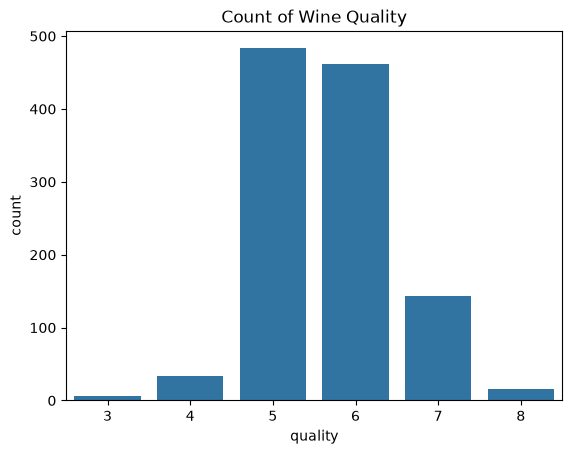

In [61]:
sb.countplot(x='quality', data=data)
plt.title('Count of Wine Quality')
plt.show()

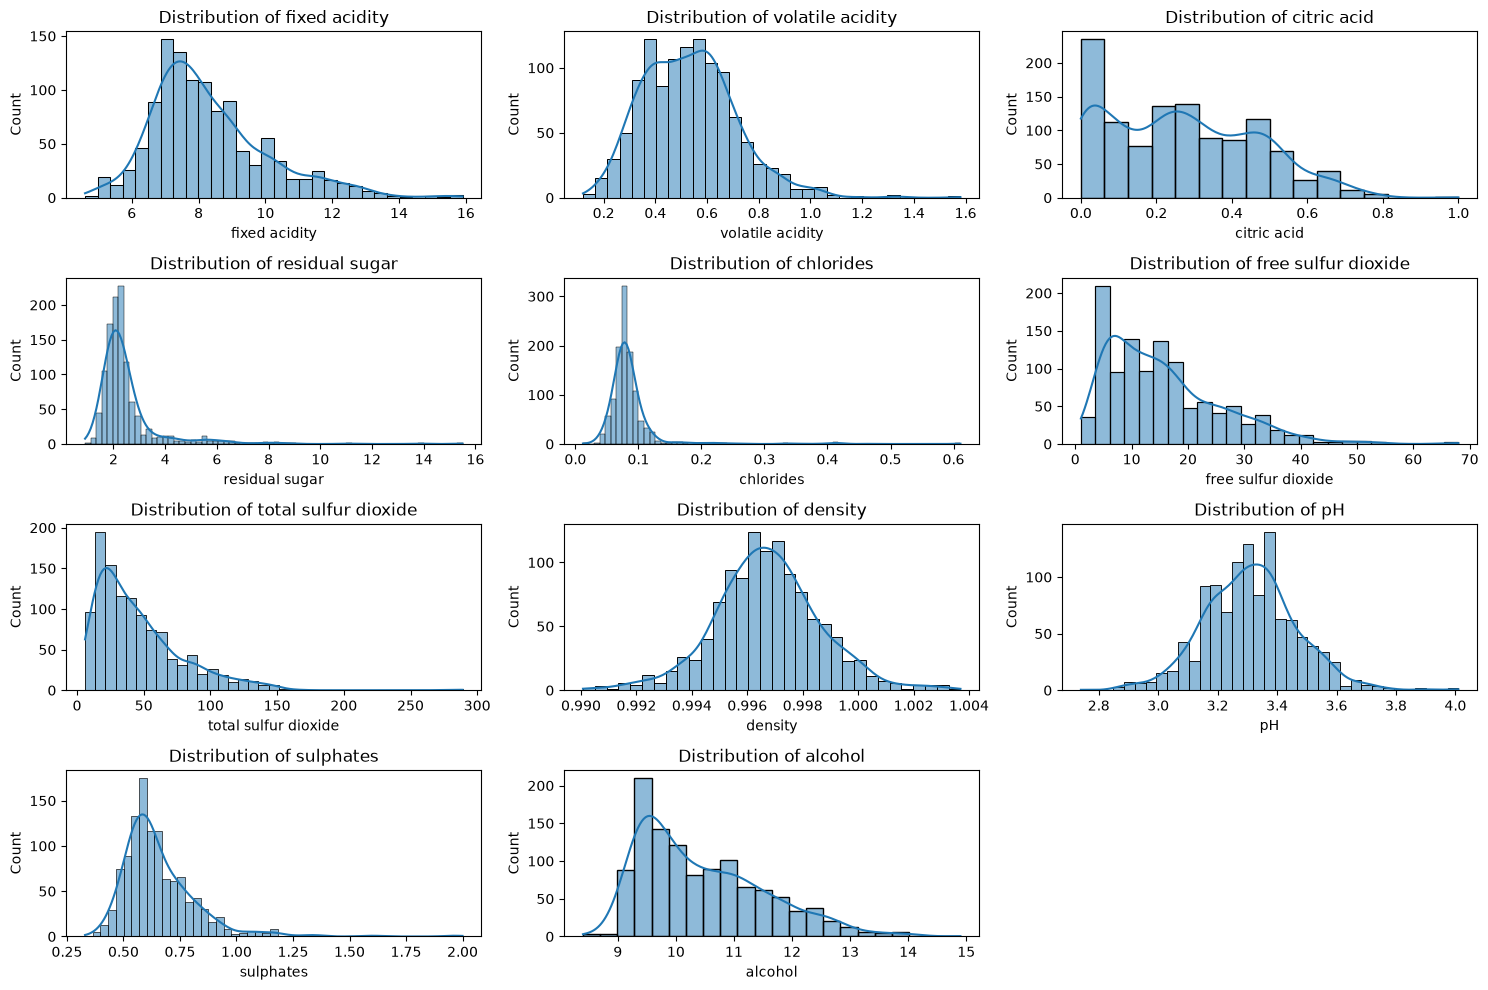

In [62]:
features = data.drop(columns='quality')

figure, axes = plt.subplots(4,3, figsize=(15, 10))
axes = axes.flatten()

# Membuat histogram untuk setiap fitur
for ax, column in enumerate(features.columns):
    sb.histplot(x=features[column], ax=axes[ax], kde=True)
    axes[ax].set_title(f'Distribution of {column}')

# Menghilangkan sumbu untuk subplot yang tidak digunakan
for i in range(len(axes)):
    if i >= len(features.columns):
        axes[i].axis('off')

plt.tight_layout()
plt.show()

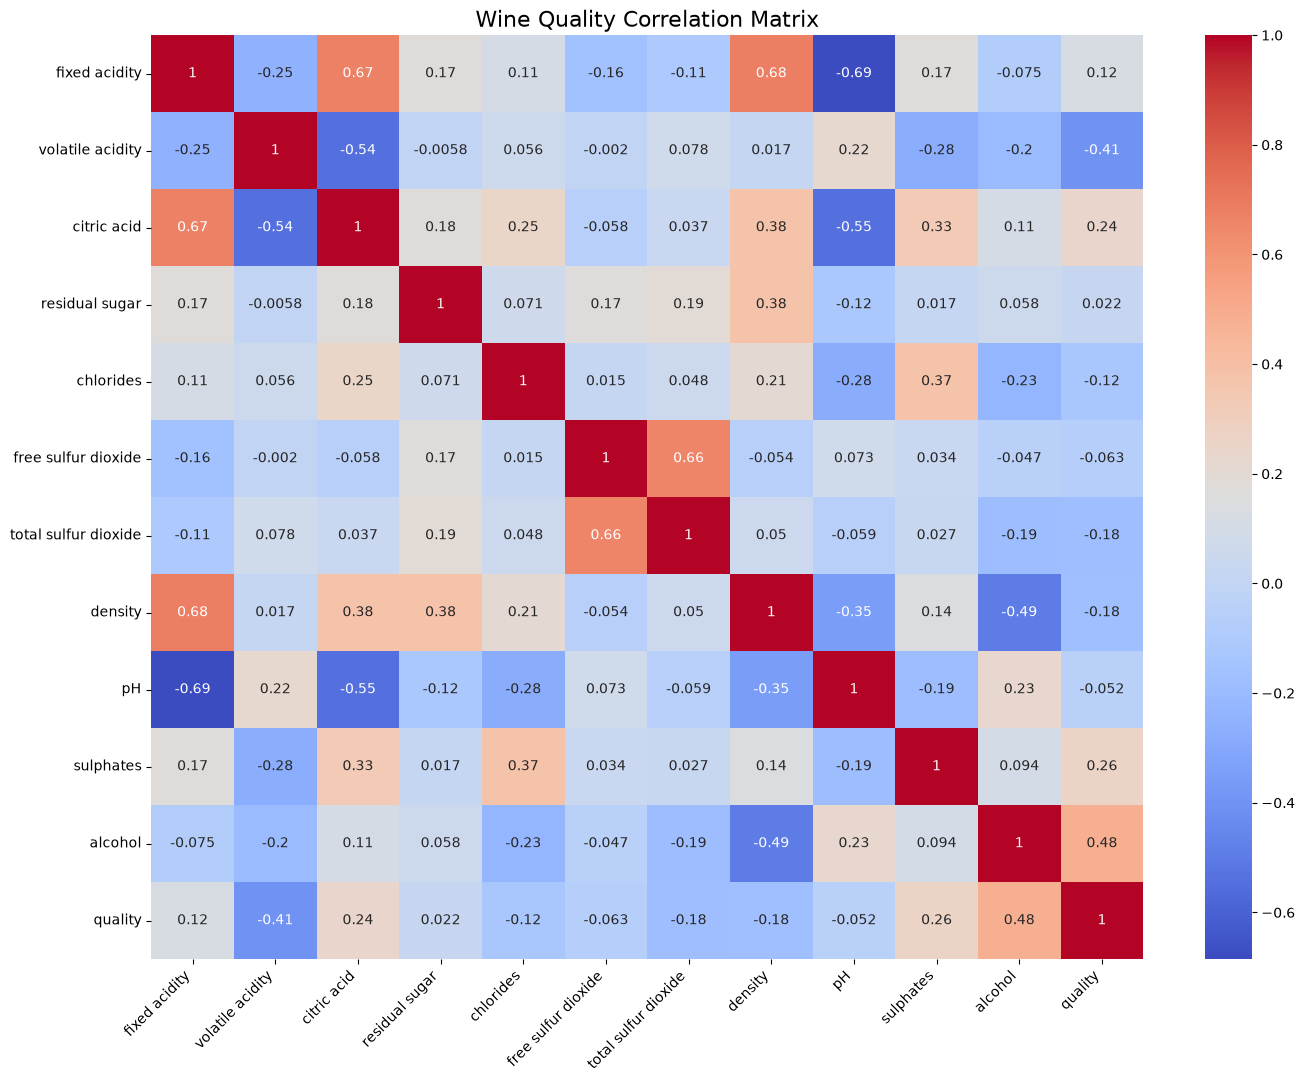

In [63]:
plt.figure(figsize=(16, 12))

sb.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
)

plt.title("Wine Quality Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

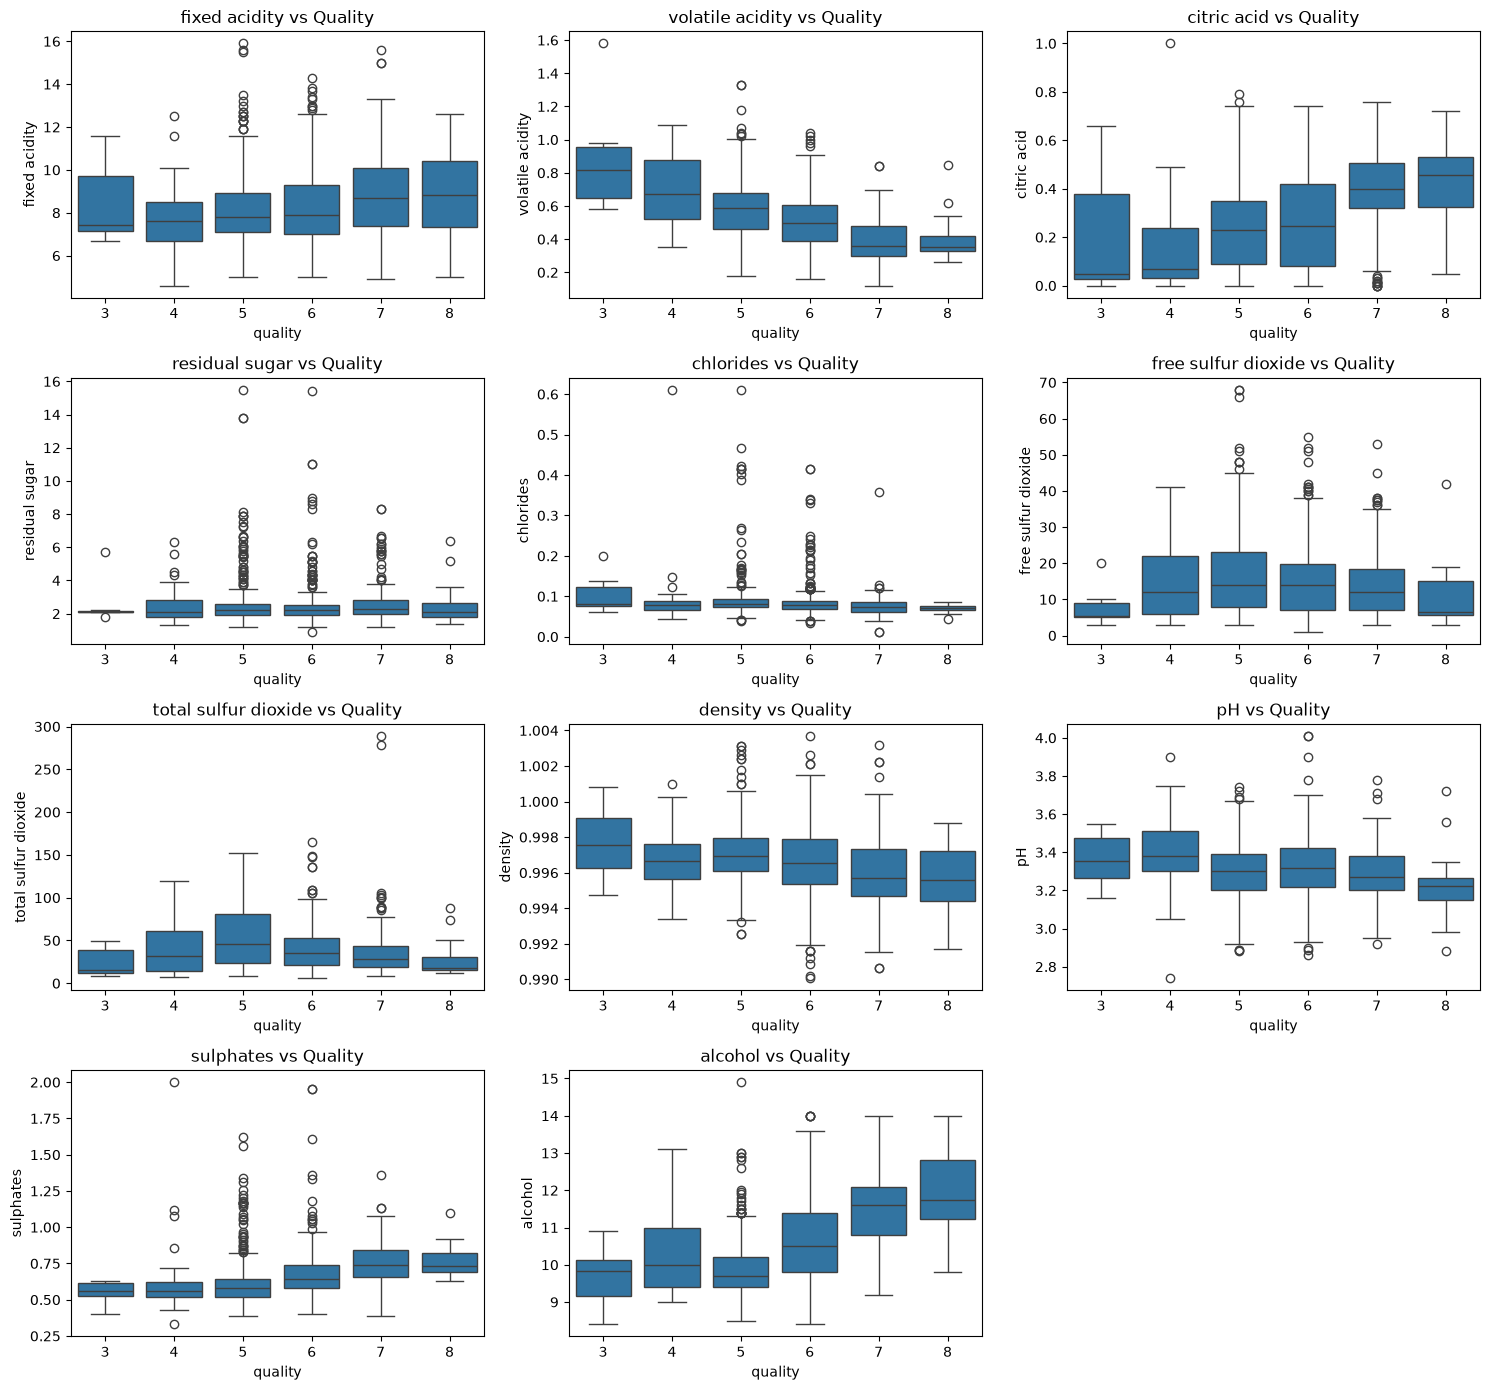

In [64]:
features = data.drop(columns='quality')

figure, axes = plt.subplots(4,3, figsize=(15, 14))
axes = axes.flatten()

# Membuat boxplot untuk setiap fitur
for ax, column in enumerate(features.columns):
    sb.boxplot(data=data, x='quality', y=column, ax=axes[ax])
    axes[ax].set_title(f'{column} vs Quality')

# Menghilangkan sumbu untuk subplot yang tidak digunakan
for i in range(len(axes)):
    if i >= len(features.columns):
        axes[i].axis('off')

plt.tight_layout()
plt.show()

# 2. Preprocessing




In [77]:
print(data.duplicated().sum())
wine = data.drop_duplicates()
print(wine.duplicated().sum())

125
0


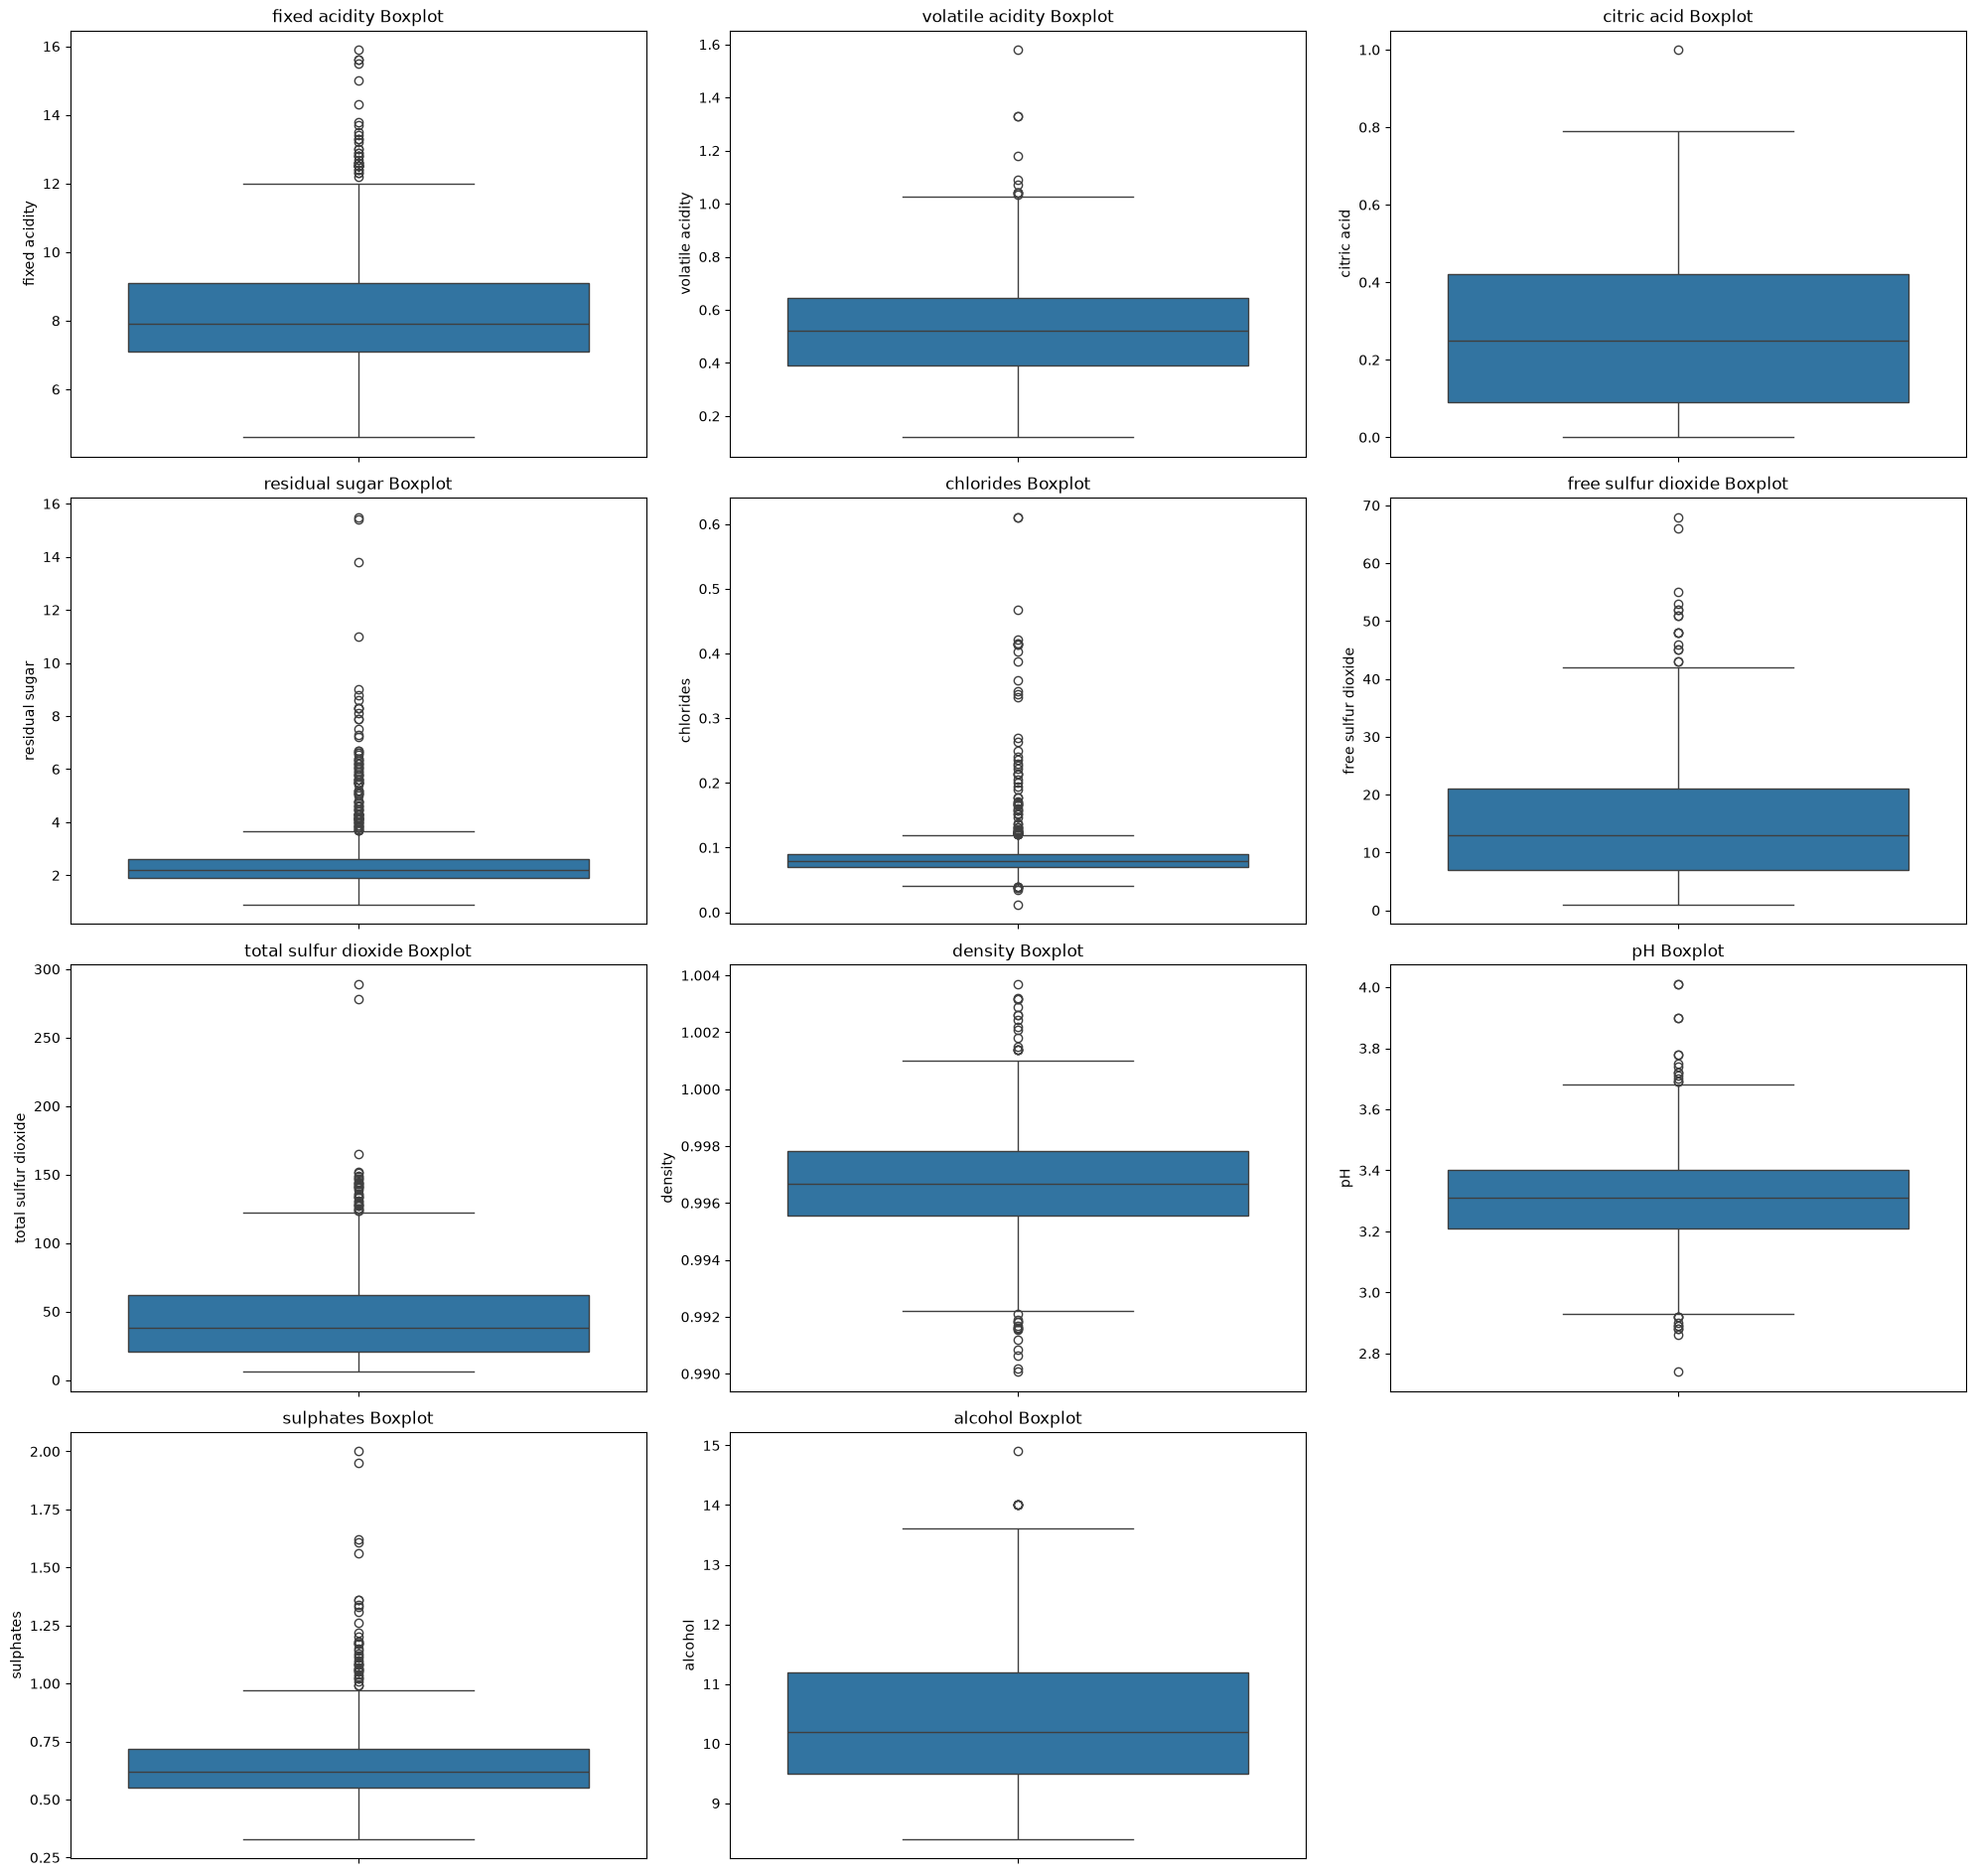

In [78]:
features = wine.drop(columns='quality')

figures, axes = plt.subplots(4, 3, figsize=(20, 19))
axes = axes.flatten()

for ax, column in enumerate(features.columns):
    sb.boxplot(data=wine, y=column, ax=axes[ax])
    axes[ax].set_title(f'{column} Boxplot')

# Menghilangkan sumbu untuk subplot yang tidak digunakan
for i in range(len(axes)):
    if i >= len(features.columns):
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [79]:
x_raw = wine.drop(columns='quality')
y_raw = wine['quality']

x_clean = x_raw.copy()
y_clean = y_raw.copy() 
x_clean = x_clean[x_clean['total sulfur dioxide'] <= 200]
y_clean = y_clean[x_clean.index]

# 3. Eksperimen Model KNN


In [80]:
datasets = {'With Outliers': (x_raw, y_raw), 'Without Outliers': (x_clean, y_clean)}
scalers = {'None': None, 'StandardScaler': StandardScaler(), 'MinMaxScaler': MinMaxScaler()}
k = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49]
metrics = ['euclidean', 'manhattan']
result = []

for name, (x, y) in datasets.items():
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

    for scaler_name, scaler in scalers.items():
        if scaler is not None:
            x_train_scaled = scaler.fit_transform(x_train)
            x_test_scaled = scaler.transform(x_test)
        else:
            x_train_scaled = x_train
            x_test_scaled = x_test

        for i in k:
            for metric in metrics:
                knn = KNeighborsClassifier(n_neighbors=i, metric=metric, weights='distance')
                knn.fit(x_train_scaled, y_train)
                y_pred = knn.predict(x_test_scaled)
                result.append({
                    'Dataset': name,
                    'Scaler': scaler_name,
                    'K': i,
                    'Metric': metric,
                    'Prediction': y_pred,
                    'Actual': y_test.values,
                    'Accuracy': accuracy_score(y_test, y_pred),
                    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
                    'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
                    })

results_df = pd.DataFrame(result)
display_df = results_df.drop(columns=['Prediction', 'Actual'])
display(display_df.sort_values('Accuracy', ascending=False).head(20))

,Dataset,Scaler,K,Metric,Accuracy,Precision,Recall,F1-Score
68,With Outliers,StandardScaler,19,euclidean,0.612745,0.582999,0.612745,0.596611
78,With Outliers,StandardScaler,29,euclidean,0.607843,0.573836,0.607843,0.589744
74,With Outliers,StandardScaler,25,euclidean,0.607843,0.575484,0.607843,0.589174
76,With Outliers,StandardScaler,27,euclidean,0.602941,0.569369,0.602941,0.585070
224,Without Outliers,StandardScaler,25,euclidean,0.602941,0.569276,0.602941,0.584261
81,With Outliers,StandardScaler,31,manhattan,0.598039,0.563562,0.598039,0.578965
80,With Outliers,StandardScaler,31,euclidean,0.598039,0.564690,0.598039,0.579522
231,Without Outliers,StandardScaler,31,manhattan,0.598039,0.561617,0.598039,0.577633
226,Without Outliers,StandardScaler,27,euclidean,0.598039,0.563084,0.598039,0.578789
133,With Outliers,MinMaxScaler,33,manhattan,0.598039,0.566254,0.598039,0.580033


# 4. Evaluasi Model


Evaluasi Model Terbaik:
Dataset: With Outliers
Scaler: StandardScaler
K: 19
Metric: euclidean
Accuracy: 0.6127

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.69      0.70      0.69        87
           6       0.57      0.65      0.61        82
           7       0.52      0.46      0.49        24
           8       0.00      0.00      0.00         3

    accuracy                           0.61       204
   macro avg       0.30      0.30      0.30       204
weighted avg       0.58      0.61      0.60       204



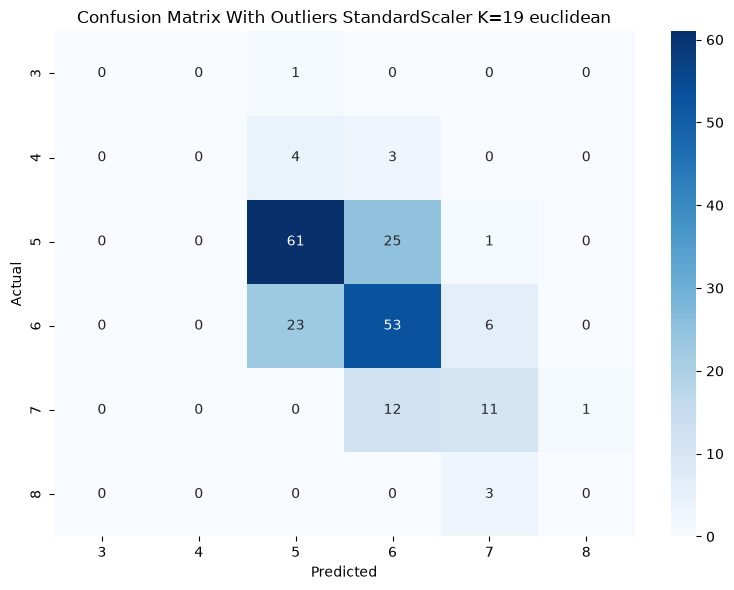

In [76]:
best_idx = results_df['Accuracy'].idxmax()
best_row = results_df.loc[best_idx]
best_prediction = best_row['Prediction']

print("Evaluasi Model Terbaik:")
print(f"Dataset: {best_row['Dataset']}")
print(f"Scaler: {best_row['Scaler']}")
print(f"K: {best_row['K']}")
print(f"Metric: {best_row['Metric']}")
print(f"Accuracy: {best_row['Accuracy']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, best_prediction, zero_division=0))

labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, best_prediction, labels=labels)

plt.figure(figsize=(8, 6))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title(f"Confusion Matrix {best_row['Dataset']} "f"{best_row['Scaler']} K={best_row['K']} "f"{best_row['Metric']}")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 5. Analisis

### 1. Konfigurasi Model Terbaik
Berdasarkan hasil eksperimen, konfigurasi terbaik diperoleh menggunakan dataset With Outliers, StandardScaler, nilai K sebesar 19, dan metrik Euclidean. Model tersebut menghasilkan accuracy sebesar 0,6127 atau 61,27%, weighted precision sebesar 0,5830 atau 58,30%, weighted recall sebesar 0,6127 atau 61,27%, serta weighted F1-score sebesar 0,5966 atau 59,66%.

Nilai accuracy sebesar 61,27% menunjukkan bahwa model mampu memberikan prediksi yang benar terhadap sekitar 61% data pengujian. Namun, nilai precision dan F1-score yang lebih rendah daripada accuracy mengindikasikan bahwa kemampuan model dalam melakukan klasifikasi belum sepenuhnya merata pada seluruh kelas kualitas wine. Dengan kata lain, model dapat mencapai jumlah prediksi benar yang cukup tinggi secara keseluruhan, tetapi ketepatan prediksi pada beberapa kelas masih relatif rendah.

### 2. Perbandingan Dataset dengan dan Tanpa Outlier

Model terbaik pada dataset With Outliers memperoleh accuracy sebesar 61,27% dan F1-score sebesar 59,66% dengan konfigurasi StandardScaler, K=19, dan metrik Euclidean. Sementara itu, model terbaik pada dataset Without Outliers memperoleh accuracy sebesar 60,29% dan F1-score sebesar 58,43% dengan konfigurasi StandardScaler, K=25, dan metrik Euclidean.

Berdasarkan perbandingan tersebut, penghapusan outlier belum memberikan peningkatan terhadap performa model. Accuracy mengalami penurunan sebesar 0,98 poin persentase, yaitu dari 61,27% menjadi 60,29%. F1-score juga mengalami penurunan sebesar 1,23 poin persentase, yaitu dari 59,66% menjadi 58,43%.

Hasil tersebut menunjukkan bahwa metode pembersihan data berdasarkan batas total sulfur dioxide ≤ 200 belum efektif dalam meningkatkan performa KNN pada eksperimen ini. Observasi yang dihapus belum tentu merupakan data yang salah atau tidak relevan. Nilai tersebut dapat menjadi bagian dari variasi alami dataset dan mungkin masih mengandung informasi yang membantu model mengenali karakteristik kelas tertentu.

Selain itu, penghapusan observasi menyebabkan jumlah data yang tersedia untuk pelatihan berkurang. Kondisi tersebut dapat memberikan pengaruh terhadap KNN karena metode ini melakukan prediksi berdasarkan distribusi data latih. Oleh karena itu, berdasarkan eksperimen yang telah dilakukan, dataset dengan outlier memberikan hasil yang sedikit lebih baik dibandingkan dataset tanpa outlier. Akan tetapi, hasil ini tidak berarti bahwa penghapusan outlier selalu menurunkan performa model. Kesimpulan yang dapat diberikan terbatas pada metode dan batas penghapusan outlier yang diterapkan dalam eksperimen ini.

### 3. Perbandingan Metode Scaler

StandardScaler digunakan pada 18 dari 20 konfigurasi dengan accuracy tertinggi yang tercantum dalam hasil eksperimen. Sementara itu, MinMaxScaler hanya ditemukan pada dua konfigurasi dan tidak terdapat konfigurasi tanpa scaling dalam 20 hasil tersebut.

Konfigurasi terbaik dengan StandardScaler mencapai accuracy sebesar 61,27% dan F1-score sebesar 59,66%. Adapun konfigurasi MinMaxScaler terbaik yang tercantum menggunakan dataset With Outliers, K=33, dan metrik Manhattan dengan accuracy sebesar 59,80% serta F1-score sebesar 58,00%.

Hasil tersebut menunjukkan bahwa StandardScaler lebih sesuai untuk konfigurasi model terbaik pada eksperimen ini. Hal ini mungkin disebabkan karena KNN merupakan algoritma berbasis jarak, sehingga perbedaan skala antarfitur dapat memengaruhi penentuan tetangga terdekat. Fitur dengan rentang nilai yang lebih besar berpotensi memberikan pengaruh lebih dominan dalam perhitungan jarak, sehingga StandardScaler membantu menempatkan fitur pada skala yang lebih sebanding dengan melakukan transformasi berdasarkan nilai rata-rata dan simpangan baku masing-masing fitur.

### 4. Perbandingan Metrik Euclidean dan Manhattan

Metrik Euclidean memberikan hasil terbaik dengan accuracy sebesar 61,27%, sedangkan konfigurasi Manhattan terbaik yang tersedia mencapai accuracy sebesar 59,80%. Dari 20 konfigurasi teratas, sebanyak 14 konfigurasi menggunakan Euclidean dan enam konfigurasi menggunakan Manhattan.

Selisih accuracy antara konfigurasi terbaik Euclidean dan Manhattan adalah 1,47 poin persentase. Hasil ini menunjukkan bahwa Euclidean lebih sesuai dalam menentukan kedekatan antarobservasi pada ruang fitur yang telah distandardisasi. Euclidean mengukur jarak langsung antarobservasi berdasarkan gabungan selisih kuadrat setiap fitur, sedangkan Manhattan menghitung jumlah selisih absolut pada seluruh fitur.


### 5. Pengaruh Nilai K

Nilai K menentukan jumlah tetangga yang digunakan dalam proses klasifikasi. Hasil eksperimen memperlihatkan bahwa model terbaik menggunakan K=19. Beberapa konfigurasi dengan performa tinggi lainnya menggunakan K=25, K=27, K=29, dan K=31. Sebaliknya, pada konfigurasi dengan nilai K yang lebih besar, seperti K=47 dan K=49, accuracy yang diperoleh masing-masing sebesar 59,31% dan 58,82%.

Temuan tersebut menunjukkan bahwa nilai K menengah cenderung memberikan hasil yang lebih baik pada eksperimen ini. Nilai K yang terlalu kecil dapat menyebabkan prediksi sangat dipengaruhi oleh sejumlah kecil observasi, sehingga model lebih sensitif terhadap noise. Sebaliknya, nilai K yang terlalu besar dapat memasukkan terlalu banyak tetangga dalam proses voting dan membuat model menjadi terlalu umum. Dalam kondisi tersebut, karakteristik lokal data dapat berkurang dan prediksi cenderung dipengaruhi oleh kelas dengan jumlah observasi lebih besar.

### 6. Evaluasi Keseluruhan

Secara keseluruhan, kombinasi dataset dengan outlier, StandardScaler, K=19, metrik Euclidean, dan pembobotan distance menghasilkan performa terbaik. Namun, accuracy sebesar 61,27% dan F1-score sebesar 59,66% menunjukkan bahwa kemampuan prediksi model masih terbatas


# 6. Kesimpulan dan Saran

### Kesimpulan
Berdasarkan eksperimen yang telah dilakukan, konfigurasi KNN terbaik menggunakan dataset dengan outlier, StandardScaler, K=19, metrik Euclidean, dan pembobotan distance. Konfigurasi tersebut menghasilkan accuracy sebesar 61,27%, weighted precision sebesar 58,30%, weighted recall sebesar 61,27%, dan weighted F1-score sebesar 59,66%.

Penghapusan outlier menggunakan batas total sulfur dioxide ≤ 200 tidak meningkatkan performa model. Dataset tanpa outlier menghasilkan accuracy terbaik sebesar 60,29%, lebih rendah dibandingkan dataset dengan outlier. StandardScaler menjadi metode normalisasi yang paling dominan pada konfigurasi teratas, sedangkan Euclidean memberikan hasil lebih baik daripada Manhattan. Nilai K menengah, khususnya K=19, memberikan performa terbaik, sementara peningkatan K hingga 47 dan 49 cenderung diikuti penurunan accuracy.

### Saran
Berdasarkan hasil eksperimen, beberapa pengembangan dapat dilakukan untuk memperoleh model KNN yang lebih optimal. Pertama, proses penghapusan outlier sebaiknya tidak hanya didasarkan pada satu batas nilai total sulfur dioxide. Identifikasi outlier dapat dilakukan pada seluruh fitur menggunakan metode statistik yang sesuai, seperti Interquartile Range, kemudian dibandingkan kembali dengan dataset tanpa penghapusan outlier. Hal ini diperlukan karena hasil eksperimen menunjukkan bahwa penghapusan observasi dengan total sulfur dioxide > 200 justru menurunkan accuracy dari 61,27% menjadi 60,29%.

Kedua, pemilihan fitur perlu dievaluasi lebih lanjut. Perlunya pengujian dimana fitur-fitur yang berdasarkan correlation matrix dan analysis bivariance, contohnya Chlorides perlu diuji

Ketiga, evaluasi model sebaiknya tidak hanya menggunakan satu pembagian data latih dan data uji. Penggunaan stratified cross-validation dapat dipertimbangkan agar performa setiap konfigurasi dinilai pada beberapa pembagian data. Pendekatan tersebut dapat memberikan hasil evaluasi yang lebih stabil serta mengurangi ketergantungan terhadap komposisi data pada satu train-test split